Cavity Flow (Steady) DEMO code

This notebook demonstrates solving steady-state Cavity Flow with the same setup as https://www.comsol.com/blogs/how-to-solve-a-classic-cfd-benchmark-the-lid-driven-cavity-problem.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain: a square cavity with a reference point for pressure boundary condition.

In [2]:
rectangle = df.geometry.rectangle([0, 1], [0, 1])
point = df.geometry.point(0,0)

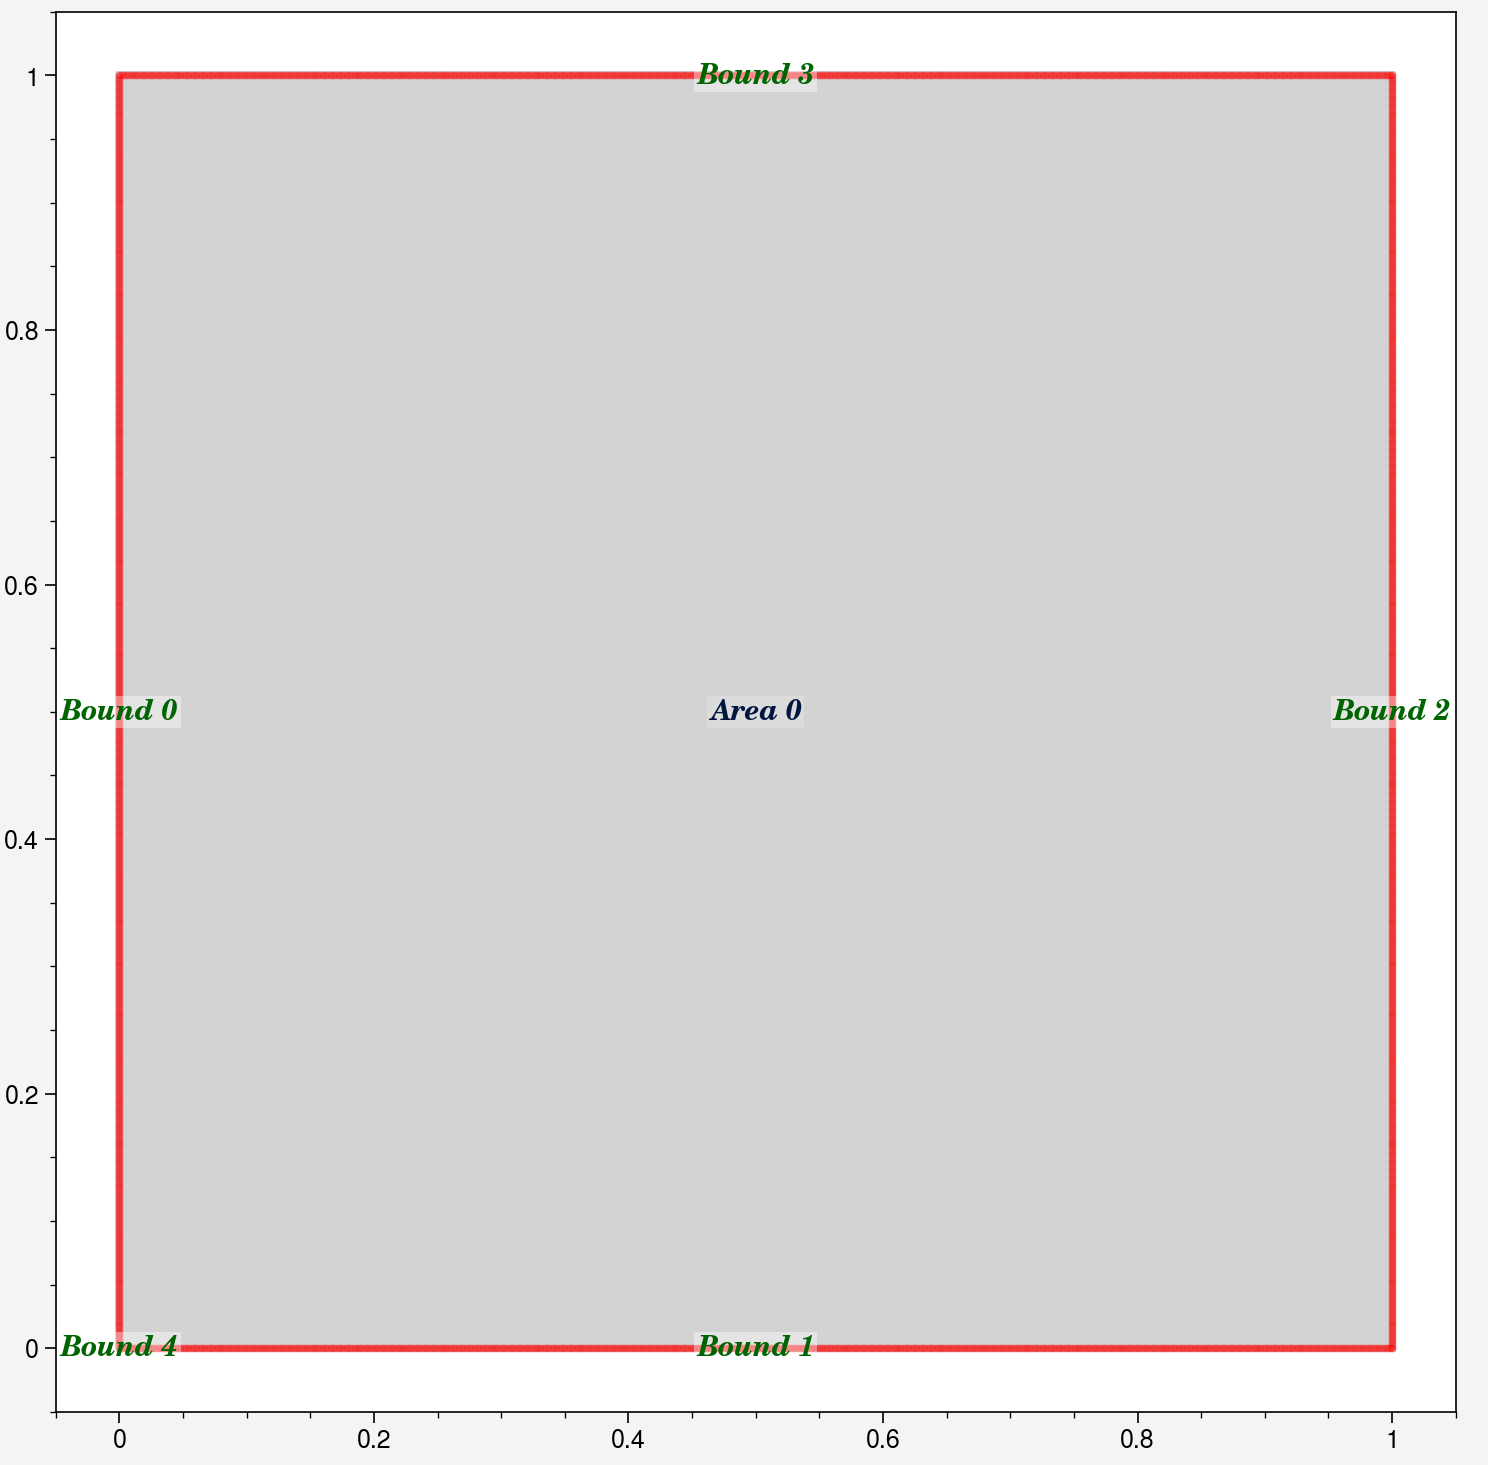

In [3]:
domain = df.domain(rectangle, point)
domain.show_setup()

## 2. Define Physics
Define the Navier-Stokes equations for fluid flow and apply boundary conditions (e.g., no-slip walls, inlet velocity).

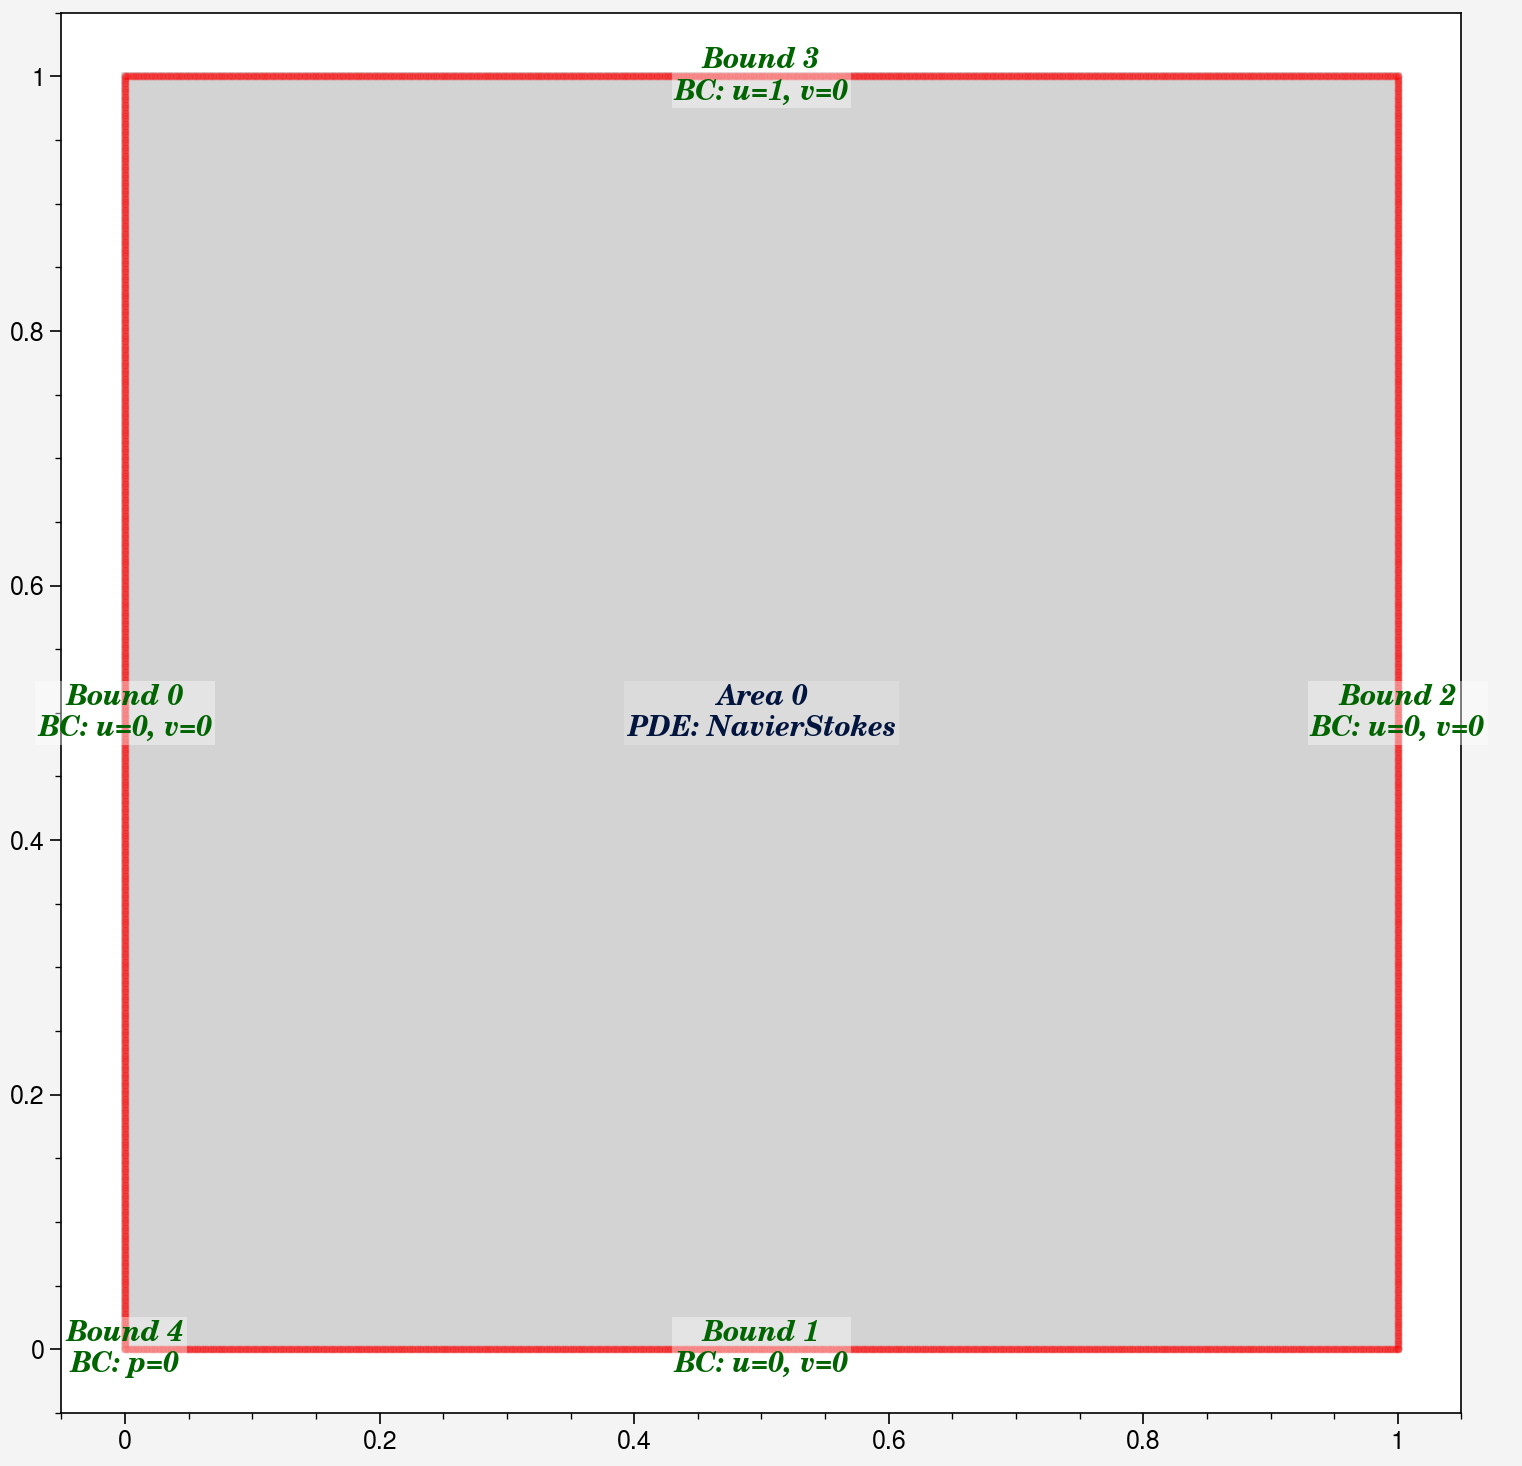

In [4]:
domain.bound_list[0].define_bc({'u': 0,'v': 0})
domain.bound_list[1].define_bc({'u': 0,'v': 0})
domain.bound_list[2].define_bc({'u': 0,'v': 0})
domain.bound_list[3].define_bc({'u': 1, 'v': 0})
domain.bound_list[4].define_bc({'p': 0})
domain.area_list[0].define_pde(df.NavierStokes(U=0.0001, L=1, mu=0.001, rho=1000))
domain.show_setup()


Sample initial points for training.

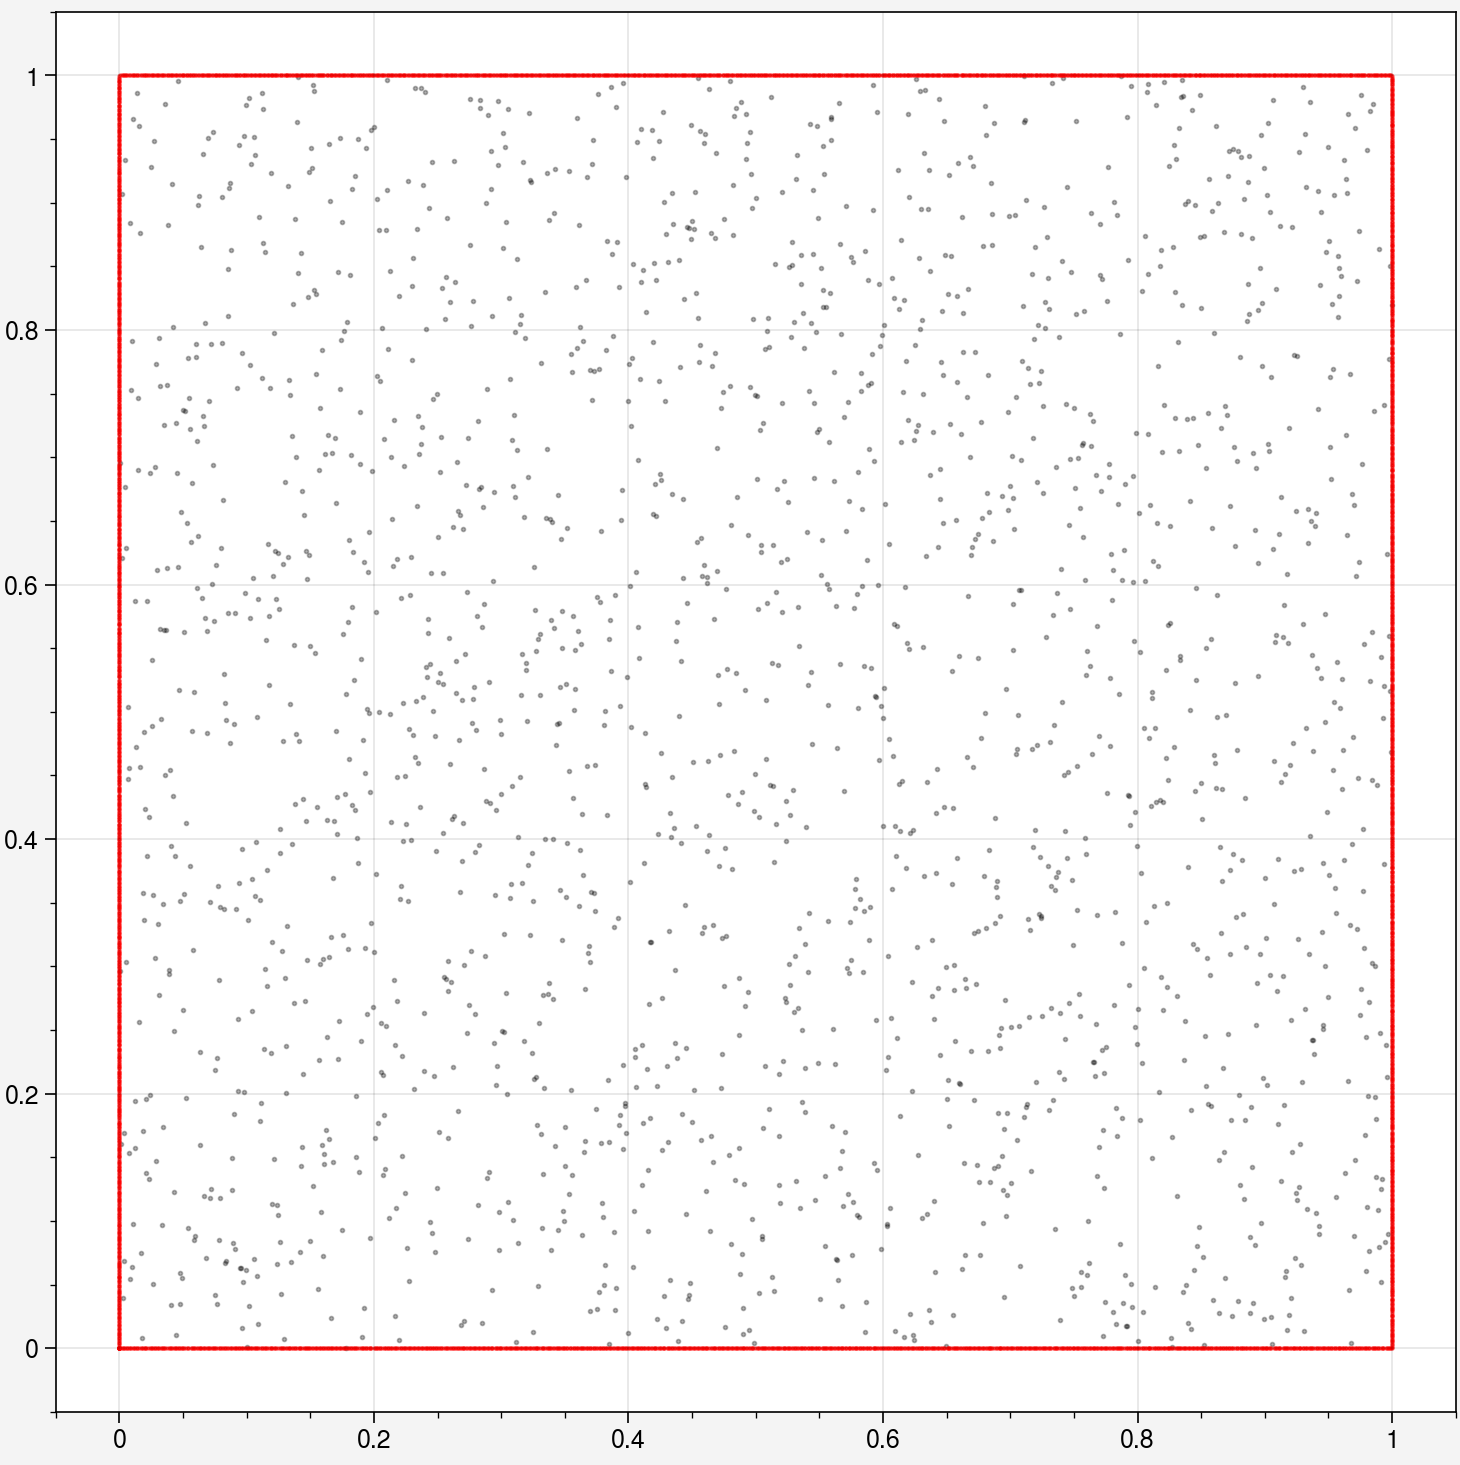

In [5]:
domain.sampling_lhs(bound_sampling_res=[1000, 1000, 1000, 1000, 10], area_sampling_res=[2000])
domain.show_coordinates(display_physics=False)

## 3. Train the PINN model

Define how collocation points are sampled during training.

In [6]:
def do_in_adam(epoch, model):
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_R3(bound_sampling_res=[1000, 1000, 1000, 1000], area_sampling_res=[2000])
        print(domain)

Train the model using Adam for initial training (faster convergence).

In [7]:
model0 = df.PINN(width=50, length=5, input_vars=['x','y'], output_vars=['u','v','p'])

# Train the model
model1, model1best = model0.train_adam(
    learning_rate=0.004,
    epochs=2000,
    calc_loss=df.calc_loss_simple(domain),
    threshold_loss=0.005,
    do_between_epochs=do_in_adam)

Epoch: 1, total_loss: 0.87961, bc_loss: 0.87752, pde_loss: 0.00209


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


Epoch: 200, total_loss: 0.12046, bc_loss: 0.10535, pde_loss: 0.01512
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


Epoch: 400, total_loss: 0.17379, bc_loss: 0.16165, pde_loss: 0.01214
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


...

Epoch: 1600, total_loss: 0.16221, bc_loss: 0.13007, pde_loss: 0.03214
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


Epoch: 1800, total_loss: 0.17590, bc_loss: 0.12981, pde_loss: 0.04609
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


Epoch: 2000, total_loss: 0.17331, bc_loss: 0.14340, pde_loss: 0.02991
number of bound : ['0: 1000', '1: 1000', '2: 1000', '3: 1000', '4: 10']
number of area : ['0: 2000']


Refine the model using LBFGS for higher precision.

In [8]:
# Train the model
model2, model2best = model1best.train_lbfgs(
    calc_loss=df.calc_loss_simple(domain),
    epochs=350,
    threshold_loss=0.0001)

Epoch: 2050, total_loss: 0.16706, bc_loss: 0.14769, pde_loss: 0.01937


Epoch: 2100, total_loss: 0.04600, bc_loss: 0.03333, pde_loss: 0.01267


Epoch: 2150, total_loss: 0.02048, bc_loss: 0.01489, pde_loss: 0.00559


Epoch: 2200, total_loss: 0.01085, bc_loss: 0.00768, pde_loss: 0.00317


Epoch: 2250, total_loss: 0.00711, bc_loss: 0.00510, pde_loss: 0.00201


Epoch: 2300, total_loss: 0.00546, bc_loss: 0.00414, pde_loss: 0.00133


Epoch: 2350, total_loss: 0.00455, bc_loss: 0.00351, pde_loss: 0.00103


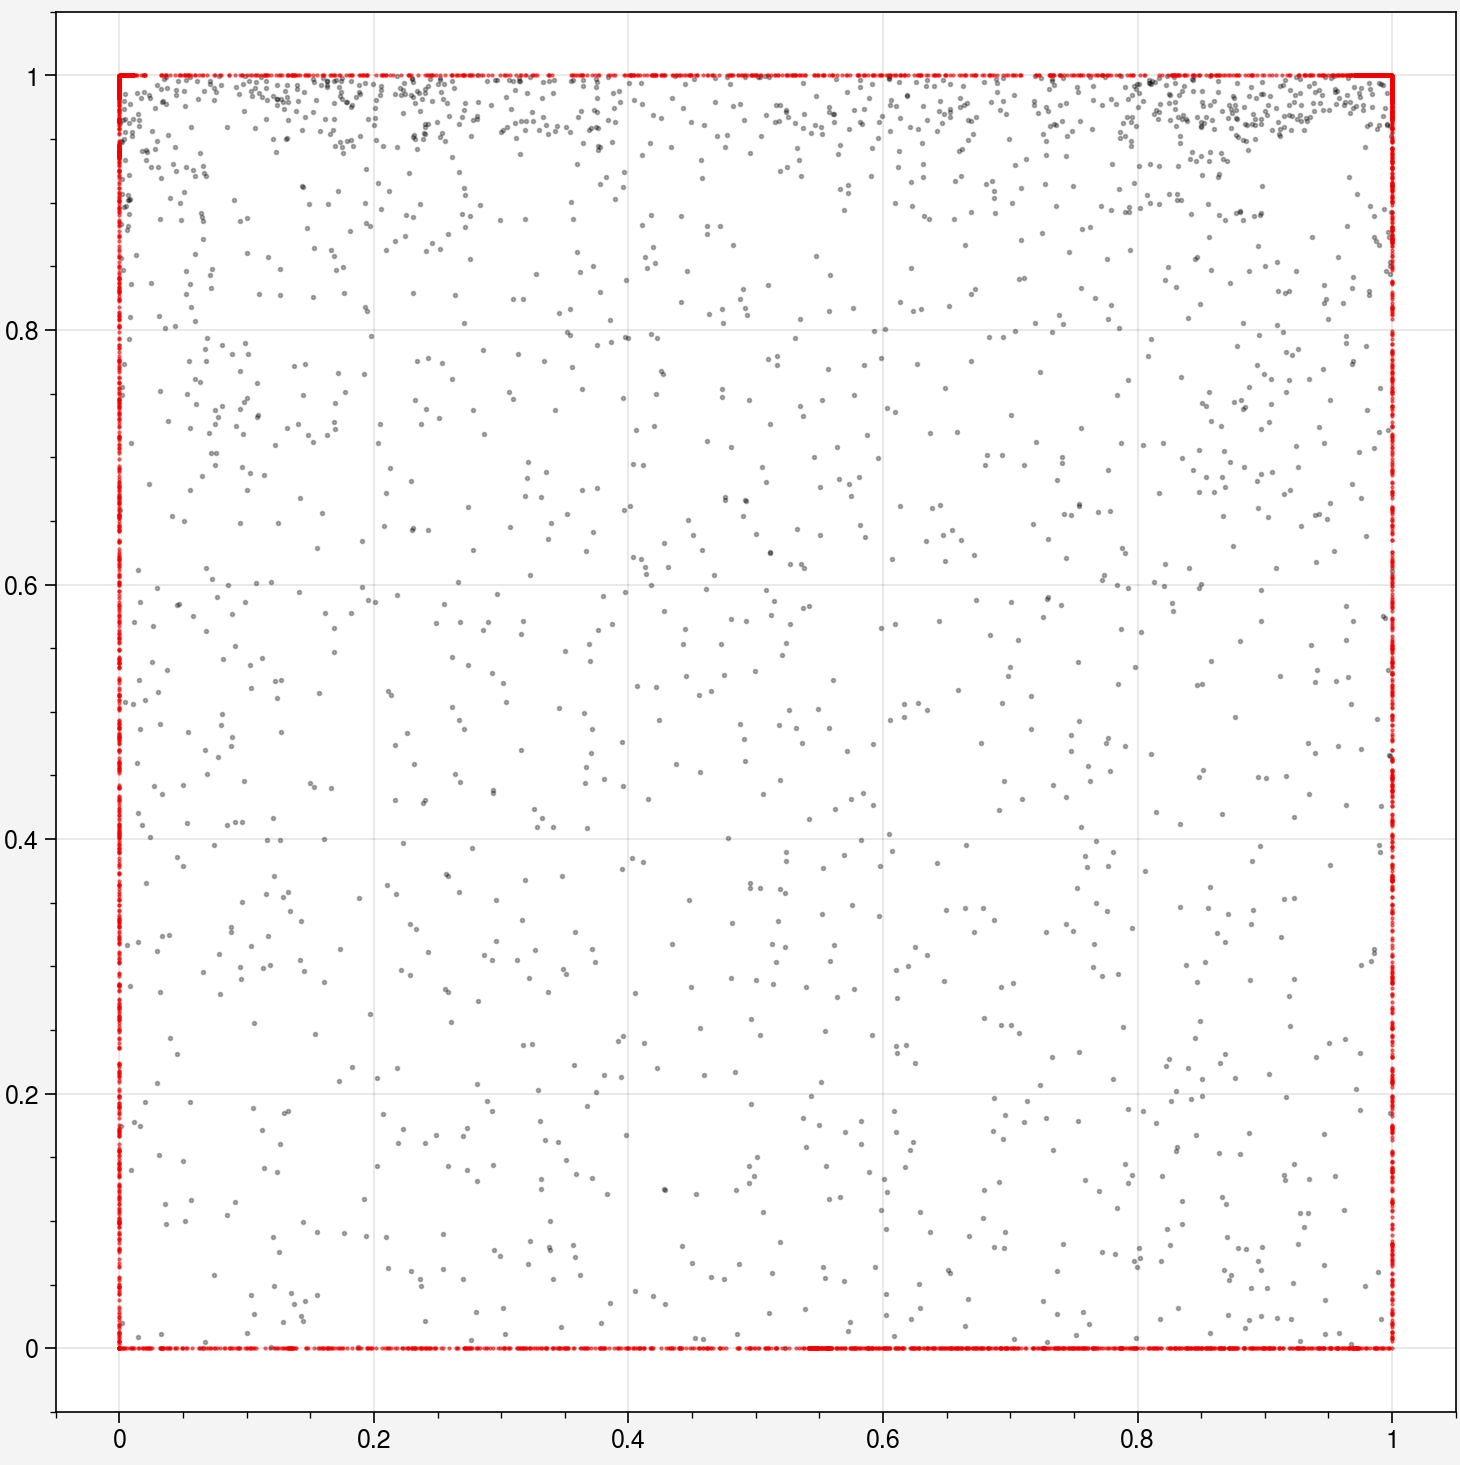

In [9]:
domain.show_coordinates()

Save or Load the model for later use

In [10]:
model2.save_as_pickle("model.pkl")
model2 = df.load_from_pickle("model.pkl")

## 4. Visualization

### 4.1 Visualize area

In [11]:
df.Visualizer.refwidth_default = 4

In [12]:
# Create object for evaluation
area_eval = domain.area_list[0].evaluate(model2)
# Sampling uniform points
area_eval.sampling_area([200, 200])
# Show available data's key
print(area_eval)

Available data keys: ('u', 'v', 'p', 'pde_residual', 'x', 'y', 'u_x', 'u_y', 'v_x', 'v_y', 'p_x', 'p_y', 'continuity_residual', 'x_momentum_residual', 'y_momentum_residual', 'total_loss', 'bc_loss', 'pde_loss')


In [13]:
area_eval['v_mag'] = (area_eval['u']**2 + area_eval['v']**2)**0.5

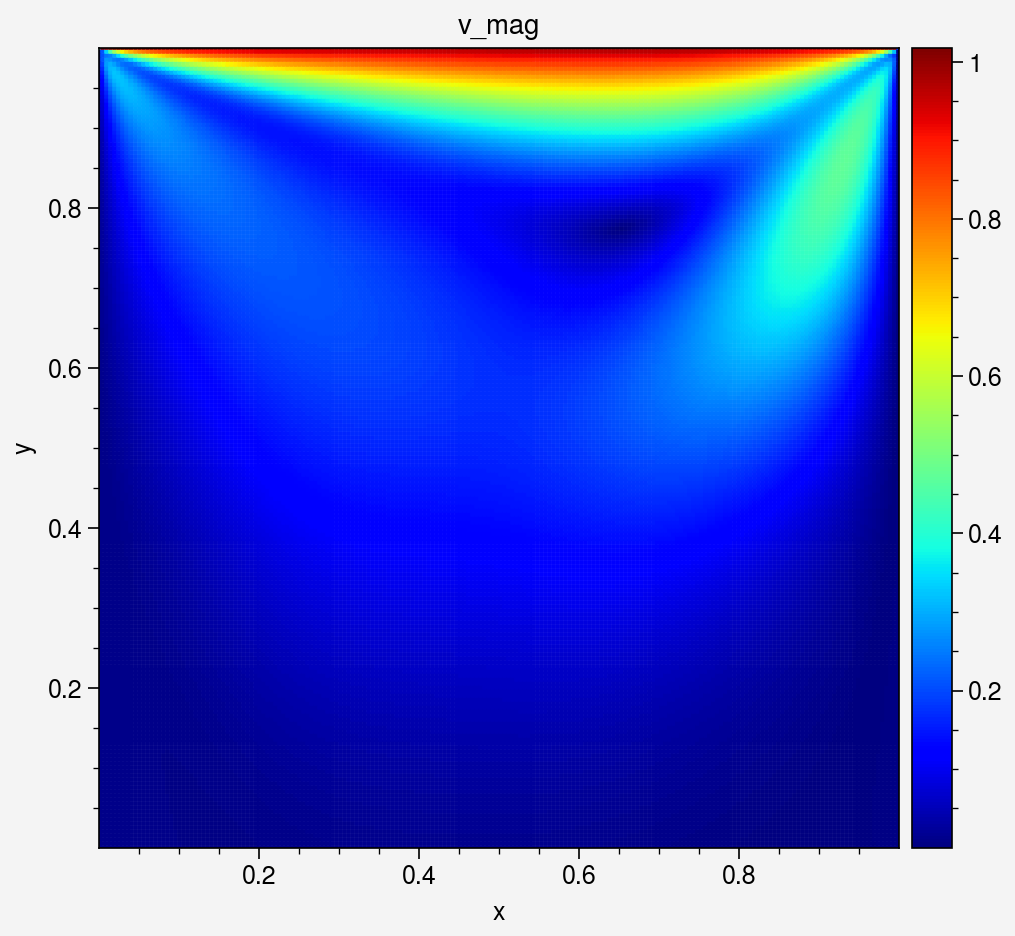

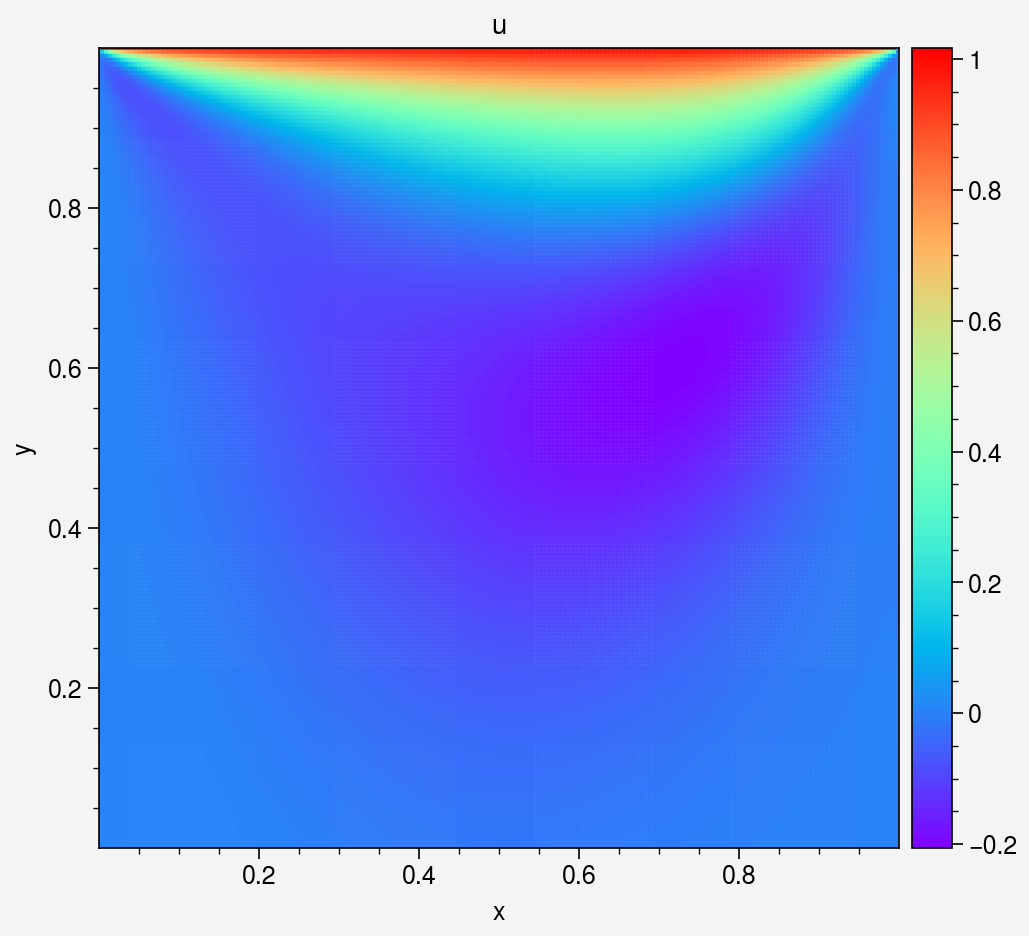

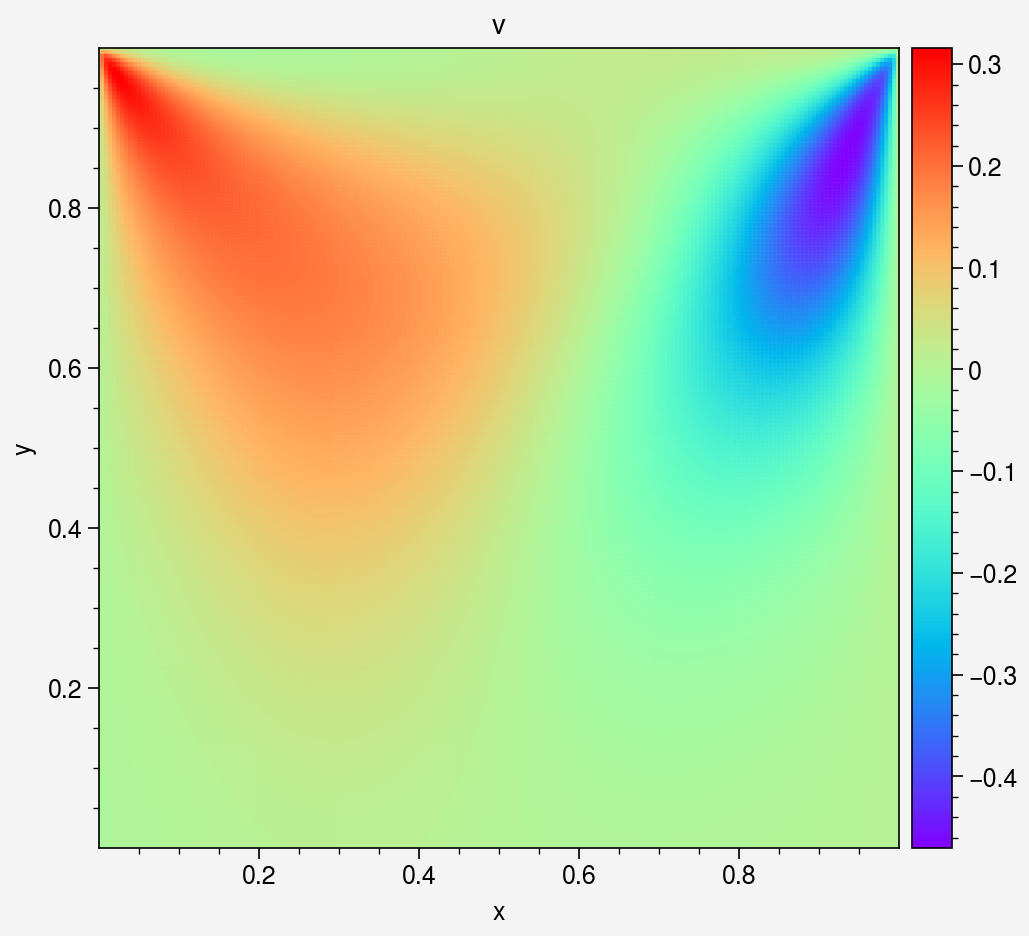

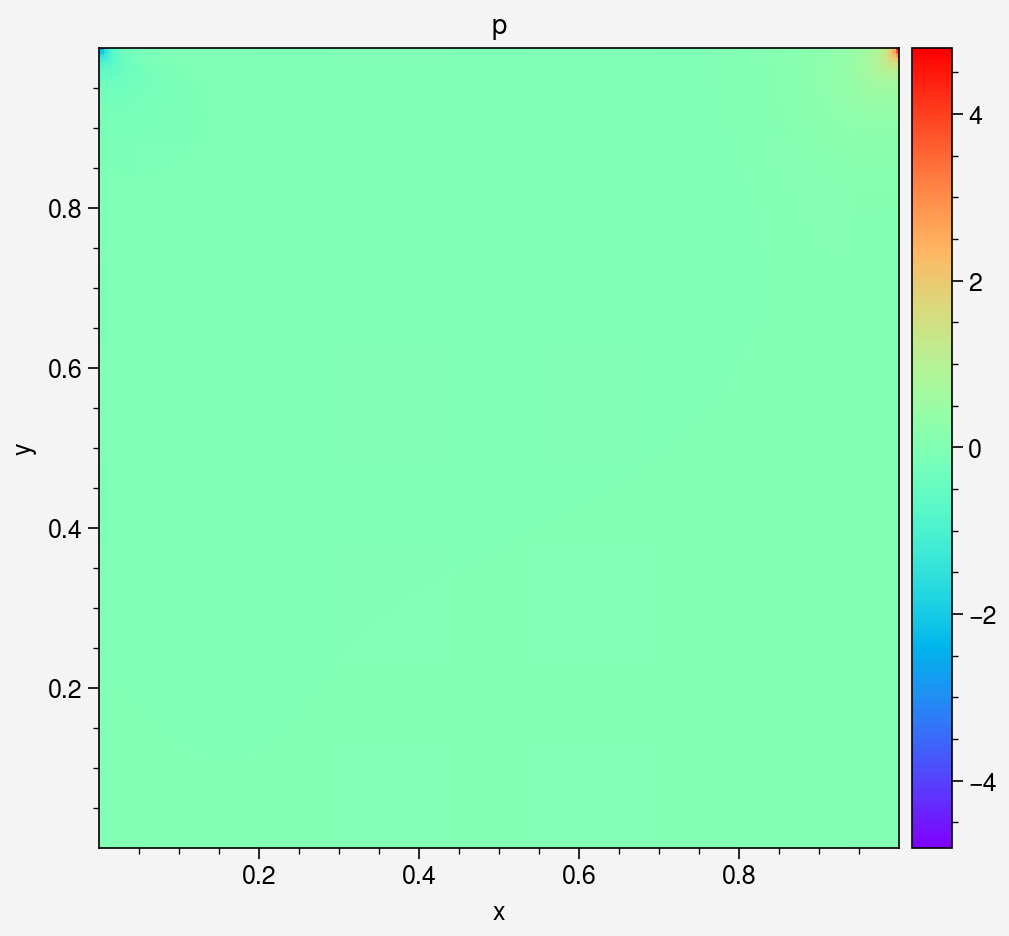

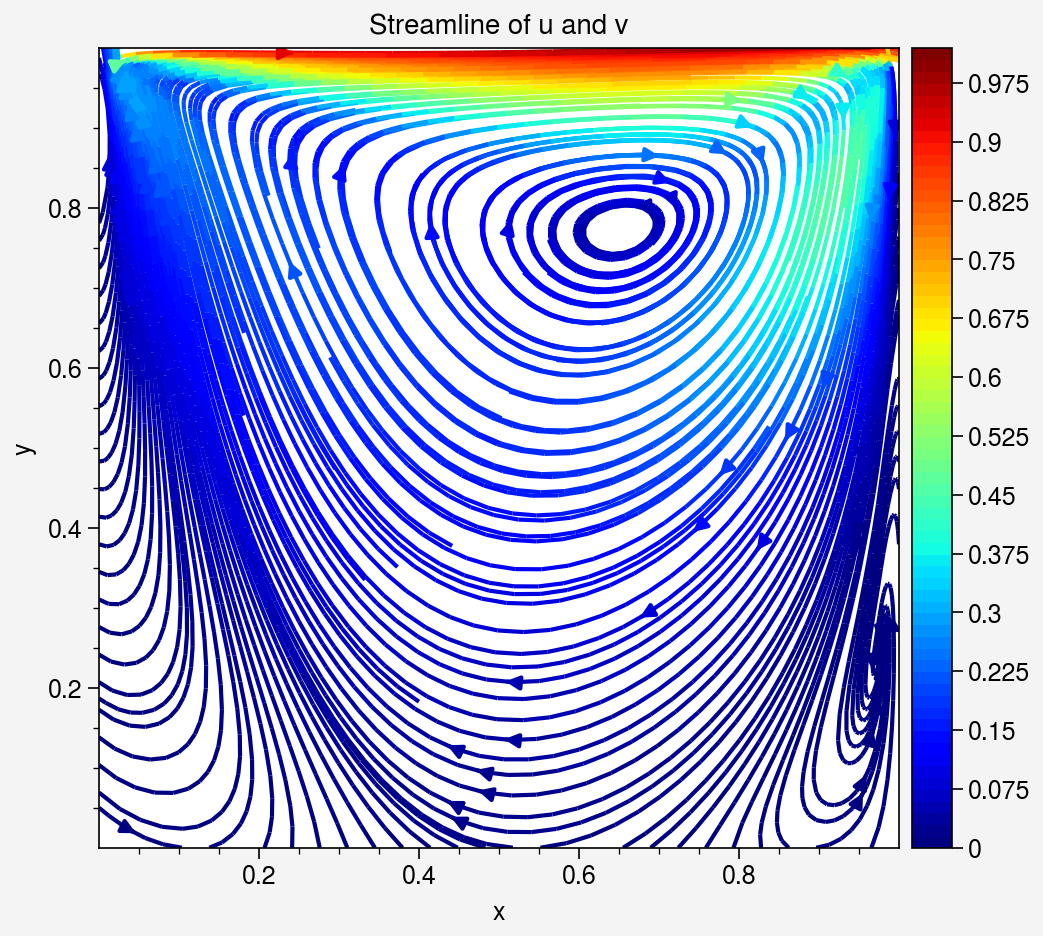

In [14]:
_ = area_eval.plot_color('v_mag', s=1.5, cmap='jet').savefig("colorplot_v_mag.png")
_ = area_eval.plot_color('u', s=1.5, cmap='rainbow')
_ = area_eval.plot_color('v', s=1.5, cmap='rainbow')
_ = area_eval.plot_color('p', s=1.5, cmap='rainbow')
_ = area_eval.plot_streamline('u', 'v', cmap = 'jet')

## 4.2 Visualize Neural Network data

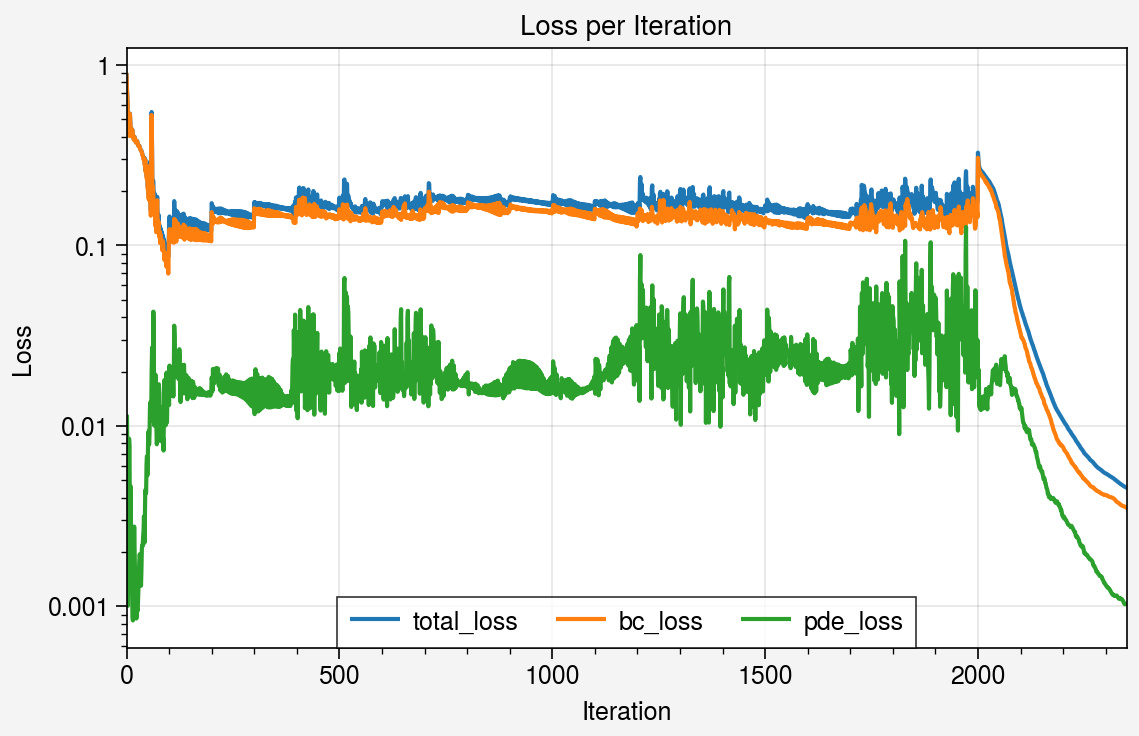

In [15]:
_ = area_eval.plot_loss_curve(log_scale=True)

### 4.4 Export data

In [16]:
# store the x,y,velocity_magnitude data
x_data = area_eval.data_dict['x']
y_data = area_eval.data_dict['y']
u_data = area_eval.data_dict['u']

#save as txt file
import numpy as np
array = np.column_stack((x_data, y_data, u_data))
np.savetxt('outlet_velocity.txt', array)

## 5. Optional FEM reference comparison

With NGSolve installed, compare the best model from the fixed-sample LBFGS phase.

In [17]:
try:
    import ngsolve  # noqa: F401
except (ImportError, OSError) as exc:
    print(f'Skipping optional FEM comparison: {exc}')
else:
    import numpy as np

    fem_reference = domain.solve_fem(
        mesh_size=0.2,
        boundary_resolution=32,
        max_iterations=20,
    )
    fem_area = fem_reference.area_list[0]
    fem_area.sampling_area([100, 100])
    fem_values = fem_area['u_ref']
    pinn_area = domain.area_list[0].evaluate(model2best)
    u_error = float(np.mean(np.abs(pinn_area.data_dict['u'] - fem_values)))
    if not np.isfinite(u_error):
        raise RuntimeError('FEM comparison produced a non-finite error')
    print(f'FEM mean absolute u error: {u_error:.6e}')

C:\Users\thamm\OneDrive\Documents\1 - Projects\0 - STEM\2 - Numerical Physics\9 - PINNs\pinn-deepflow\src\deepflow\reference\solver.py:515: RuntimeWarning: Ignoring a point-like FEM boundary condition; point Dirichlet constraints are not represented by the NGSolve boundary labels.
  boundary_conditions = _collect_boundary_conditions(domain, pde_area, geometry)


FEM mean absolute u error: 4.818374e-01
